In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# force white plot backgrounds with dark text/labels (default renders unreadable in some IDEs)
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"
plt.rcParams["text.color"] = "black"
plt.rcParams["axes.labelcolor"] = "black"
plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["xtick.color"] = "black"
plt.rcParams["ytick.color"] = "black"

In [2]:
# Import Dataset
df = pd.read_csv('social_media_screentime_mental_health_2026.csv')
df.head()

,participant_id,age,gender,occupation,region,most_used_platform,platforms_used_count,daily_screen_hours,daily_notifications,night_time_use,...,life_satisfaction_1to10,loneliness_1to10,self_esteem_1to10,fomo_1to10,social_comparison_1to10,physical_activity_days_per_week,uses_screen_time_limits,attempted_digital_detox,seeks_mental_health_support,wellbeing_band
0,P300000,33,Male,Student,Latin America,TikTok,8,3.2,172,Never,...,9,6,4,6,8,4,No,No,No,At-risk
1,P300001,23,Female,Full-time employed,Oceania,Instagram,8,4.5,38,Often,...,7,5,8,5,8,4,No,"Yes, failed",Yes,At-risk
2,P300002,56,Female,Full-time employed,Africa,Instagram,1,5.3,74,Every night,...,8,7,3,2,3,5,No,No,No,Moderate
3,P300003,13,Male,Student,Europe,YouTube,4,3.4,49,Sometimes,...,10,6,6,1,5,4,No,"Yes, failed",Yes,Moderate
4,P300004,36,Female,Student,Asia,LinkedIn,5,5.8,227,Never,...,4,6,8,7,9,3,Yes,"Yes, succeeded",No,Moderate


In [3]:
# Step 2: Initialize Parameters
def initialize_parameters(layer_sizes):
    # layer_sizes is a list like [n_input, n_hidden_1, n_hidden_2, ..., n_output]
    np.random.seed(1)
    parameters = []
    for i in range(1, len(layer_sizes)):
        # weights for layer i (rows = previous layer size, cols = this layer size)
        # We use He initialization to scale the weights with the number of inputs:
        W = np.random.randn(layer_sizes[i - 1], layer_sizes[i]) * np.sqrt(2 / layer_sizes[i - 1])
        b = np.zeros((1, layer_sizes[i]))
        parameters.append({"weights": W, "biases": b})
    return parameters

In [4]:
# Function to print the parameters
def print_parameters(parameters):
    for i, layer in enumerate(parameters, start=1):
        print(f"W{i} (weights for layer {i}):")
        print(layer["weights"])
        print(f"\nb{i} (biases for layer {i}):")
        print(layer["biases"])
        print()

# Initialize parameters for a network with two hidden layers (32, 16 neurons)
layer_sizes = [6, 32, 16, 3]
parameters = initialize_parameters(layer_sizes)

# Print parameters in a pretty format
print_parameters(parameters)

W1 (weights for layer 1):
[[ 0.93781623 -0.35319773 -0.3049401  -0.61947872  0.49964333 -1.32879399
   1.00736754 -0.43948301  0.18419731 -0.14397405  0.84414841 -1.18942279
  -0.18614766 -0.22173389  0.65458209 -0.63502252 -0.09955147 -0.50683179
   0.02437212  0.33648852 -0.63544278  0.66090654  0.52053365  0.29011524
   0.52010942 -0.39475046 -0.0709507  -0.54026673 -0.15466525  0.30620087
  -0.39933052 -0.22906576]
 [-0.39673934 -0.4879797  -0.38754413 -0.00731191 -0.64507943  0.13533997
   0.95828723  0.4284194  -0.11075631 -0.51247282 -0.43137204  0.97713912
   0.02933387 -0.36776961  0.11022511  1.21258287  0.0693738   0.35634238
   0.17330342 -0.20337154 -0.65963319 -0.20169311 -0.12060514  0.33868706
   0.4843873   0.53757204  0.16488392  0.51103649 -0.43555185  0.72334377
   0.29614017 -0.17210398]
 [ 0.28204608 -0.04363135  0.65334653  0.87746665  1.26184255 -0.80626754
  -0.83375949 -0.2912535   0.09239745  0.50585636  0.18223192 -1.16751842
  -0.17678697  0.47803138  0.132

In [5]:
def relu(Z):
    return np.maximum(0, Z)

def relu_derivative(Z):
    return Z > 0

def softmax(Z):
    # subtract the row-wise max first so the exponentials don't blow up
    shifted = Z - np.max(Z, axis=1, keepdims=True)
    e = np.exp(shifted)
    return e / np.sum(e, axis=1, keepdims=True)

In [6]:
# Step 4: Forward Propagation
def forward_propagation(X, parameters, output_activation="softmax"):
    # caches stores Z and A for every layer so backprop can reuse them
    # Z is the value before the activation function is applied
    # A is the value after the activation function is applied
    caches = []
    A = X
    num_layers = len(parameters)
    for i, layer in enumerate(parameters):
        # linear combination for this layer
        Z = np.dot(A, layer["weights"]) + layer["biases"]
        if i == num_layers - 1:
            # classification uses softmax, regression uses a linear output
            if output_activation == "softmax":
                A = softmax(Z)
            else:
                A = Z
        else:
            # every hidden layer uses ReLU
            A = relu(Z)
        caches.append({"Z": Z, "A": A})
    return caches

In [7]:
# Step 5: Compute Cost
def compute_cost(A_final, Y, loss="cross_entropy", parameters=None, l2_lambda=0.0):
    # Number of examples
    m = Y.shape[0]
    if loss == "cross_entropy":
        # categorical cross-entropy, used for classification
        epsilon = 1e-8
        cost = -1 / m * np.sum(Y * np.log(A_final + epsilon))
    else:
        # mean squared error, used for regression
        cost = np.mean((A_final - Y) ** 2)

    # L2 regularization: penalize large weights so the network
    # is rewarded for shrinking weights on unhelpful features toward zero
    if parameters is not None and l2_lambda > 0:
        l2_cost = sum(np.sum(layer["weights"] ** 2) for layer in parameters)
        cost += (l2_lambda / (2 * m)) * l2_cost

    return np.squeeze(cost)

In [8]:
# Step 6: Backward Propagation
def backward_propagation(X, Y, parameters, caches, loss="cross_entropy", l2_lambda=0.0):
    # Number of examples
    m = X.shape[0]
    num_layers = len(parameters)
    grads = [None] * num_layers

    if loss == "cross_entropy":
        # softmax output combined with cross-entropy simplifies to this
        dZ = caches[-1]["A"] - Y
    else:
        # linear output combined with mean squared error
        dZ = 2 * (caches[-1]["A"] - Y)

    for i in reversed(range(num_layers)):
        A_prev = caches[i - 1]["A"] if i > 0 else X

        # Compute gradient of cost with respect to W and b for this layer
        dW = 1 / m * np.dot(A_prev.T, dZ)
        db = 1 / m * np.sum(dZ, axis=0, keepdims=True)

        # add the L2 penalty's gradient, which shrinks W toward zero
        # every update, proportional to its own current size
        if l2_lambda > 0:
            dW = dW + (l2_lambda / m) * parameters[i]["weights"]

        grads[i] = {"dW": dW, "db": db}

        if i > 0:
            # Compute gradient of cost with respect to A_prev
            dA_prev = np.dot(dZ, parameters[i]["weights"].T)
            # Compute gradient of cost with respect to Z using ReLU derivative
            dZ = dA_prev * relu_derivative(caches[i - 1]["Z"])

    return grads

In [9]:
# Step 7: Update Parameters in gradient descent
def update_parameters(parameters, grads, learning_rate):
    for layer, grad in zip(parameters, grads):
        layer["weights"] = layer["weights"] - learning_rate * grad["dW"]
        layer["biases"] = layer["biases"] - learning_rate * grad["db"]
    return parameters

In [10]:
# Step 8: Train the Neural Network
def train(X_train, Y_train, X_validation, Y_validation, layer_sizes,
          learning_rate=0.01, epochs=500, batch_size=256, print_every=25,
          output_activation="softmax", loss="cross_entropy", l2_lambda=0.0):
    # Initialize parameters
    parameters = initialize_parameters(layer_sizes)

    history = {
        "train_loss": [],
        "validation_loss": [],
        "train_metric": [],
        "validation_metric": [],
    }

    m = X_train.shape[0]

    # Gradient descent loop
    for epoch in range(epochs):
        # shuffle the training data at the start of every epoch
        permutation = np.random.permutation(m)
        X_shuffled = X_train[permutation]
        Y_shuffled = Y_train[permutation]

        # split into mini-batches and take one gradient step per batch,
        # instead of a single step over the whole training set
        for start in range(0, m, batch_size):
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            Y_batch = Y_shuffled[start:end]

            # Forward propagation
            caches = forward_propagation(X_batch, parameters, output_activation)
            # Backward propagation
            grads = backward_propagation(X_batch, Y_batch, parameters, caches, loss, l2_lambda)
            # Update parameters
            parameters = update_parameters(parameters, grads, learning_rate)

        # Compute cost on the full training set for reporting
        train_caches = forward_propagation(X_train, parameters, output_activation)
        cost = compute_cost(train_caches[-1]["A"], Y_train, loss, parameters, l2_lambda)

        # Track validation loss
        validation_caches = forward_propagation(X_validation, parameters, output_activation)
        validation_cost = compute_cost(validation_caches[-1]["A"], Y_validation, loss, parameters, l2_lambda)

        # the "metric" is accuracy for classification, mean absolute error for regression
        if loss == "cross_entropy":
            train_metric = np.mean(
                np.argmax(train_caches[-1]["A"], axis=1) == np.argmax(Y_train, axis=1)
            )
            validation_metric = np.mean(
                np.argmax(validation_caches[-1]["A"], axis=1) == np.argmax(Y_validation, axis=1)
            )
        else:
            train_metric = np.mean(np.abs(train_caches[-1]["A"] - Y_train))
            validation_metric = np.mean(np.abs(validation_caches[-1]["A"] - Y_validation))

        history["train_loss"].append(cost)
        history["validation_loss"].append(validation_cost)
        history["train_metric"].append(train_metric)
        history["validation_metric"].append(validation_metric)

        # Print cost every print_every iterations
        if epoch % print_every == 0:
            print(
                f"Epoch {epoch}: train_loss={cost:.4f} "
                f"val_loss={validation_cost:.4f} "
                f"train_metric={train_metric:.3f} "
                f"val_metric={validation_metric:.3f}"
            )

    return parameters, history

In [11]:
# Step 10: Make a prediction
def predict(X, parameters, output_activation="softmax"):
    # Forward propagation
    caches = forward_propagation(X, parameters, output_activation)
    if output_activation == "softmax":
        # Pick the class with the highest probability for each example
        return np.argmax(caches[-1]["A"], axis=1)
    else:
        # regression: return the raw predicted value
        return caches[-1]["A"].reshape(-1)

In [12]:
# Step 11: Evaluate the Model
def evaluate_model(X, Y_labels, parameters):
    predictions = predict(X, parameters)
    accuracy = np.mean(predictions == Y_labels) * 100
    return accuracy

### preprocessing

In [13]:
# Choosing input columns (shared by both target variables below)
feature_columns = [
    "daily_screen_hours",
    "avg_sleep_hours"
]

X = df[feature_columns]

# Target 1: wellbeing_band (classification)
class_names = [
    "At-risk",
    "Moderate",
    "Good",
]

class_to_number = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

y_wellbeing = df["wellbeing_band"].map(class_to_number).to_numpy()

# one-hot encode the labels, since the wellbeing output layer uses softmax
Y_wellbeing_onehot = np.eye(len(class_names))[y_wellbeing]

# Target 2: life_satisfaction_1to10 (regression)
y_life_satisfaction = df["life_satisfaction_1to10"].to_numpy().reshape(-1, 1).astype(float)

In [14]:
numeric_features = [
    "daily_screen_hours",
    "avg_sleep_hours"
]
categorical_features = [
]

numeric_pipeline = Pipeline(steps=[
    ("imputing", SimpleImputer(strategy="median")),
    ("scaling", StandardScaler()),
])

categorical_pipeline = Pipeline(steps=[
    ("imputing", SimpleImputer(strategy="most_frequent")),
    ("one_hot_encoding", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

In [15]:
# split into train / validation / test (60% / 20% / 20%)
# both targets share the same rows, so they are split together
(
    X_train_raw, X_temp_raw,
    Y_wellbeing_train, Y_wellbeing_temp,
    y_life_satisfaction_train, y_life_satisfaction_temp,
) = train_test_split(
    X, Y_wellbeing_onehot, y_life_satisfaction,
    test_size=0.4, random_state=42, stratify=y_wellbeing
)
(
    X_validation_raw, X_test_raw,
    Y_wellbeing_validation, Y_wellbeing_test,
    y_life_satisfaction_validation, y_life_satisfaction_test,
) = train_test_split(
    X_temp_raw, Y_wellbeing_temp, y_life_satisfaction_temp,
    test_size=0.5, random_state=42, stratify=np.argmax(Y_wellbeing_temp, axis=1)
)

# fit the preprocessor on the training data only, then reuse it everywhere else
X_train_processed = preprocessor.fit_transform(X_train_raw)
X_validation_processed = preprocessor.transform(X_validation_raw)
X_test_processed = preprocessor.transform(X_test_raw)

### training — wellbeing_band classifier

In [16]:
layer_sizes_wellbeing = [X_train_processed.shape[1], 32, 16, len(class_names)]

parameters_wellbeing, history_wellbeing = train(
    X_train=X_train_processed,
    Y_train=Y_wellbeing_train,
    X_validation=X_validation_processed,
    Y_validation=Y_wellbeing_validation,
    layer_sizes=layer_sizes_wellbeing,
    learning_rate=0.01,
    epochs=500,
    batch_size=64,
    print_every=25,
    output_activation="softmax",
    loss="cross_entropy",
    l2_lambda=1.0,
)

Epoch 0: train_loss=0.9304 val_loss=0.9523 train_metric=0.520 val_metric=0.531
Epoch 25: train_loss=0.8657 val_loss=0.8816 train_metric=0.562 val_metric=0.567
Epoch 50: train_loss=0.8617 val_loss=0.8704 train_metric=0.565 val_metric=0.569
Epoch 75: train_loss=0.8608 val_loss=0.8652 train_metric=0.565 val_metric=0.569
Epoch 100: train_loss=0.8605 val_loss=0.8629 train_metric=0.569 val_metric=0.571
Epoch 125: train_loss=0.8603 val_loss=0.8617 train_metric=0.566 val_metric=0.571
Epoch 150: train_loss=0.8602 val_loss=0.8606 train_metric=0.566 val_metric=0.571
Epoch 175: train_loss=0.8602 val_loss=0.8598 train_metric=0.565 val_metric=0.572
Epoch 200: train_loss=0.8600 val_loss=0.8594 train_metric=0.565 val_metric=0.571
Epoch 225: train_loss=0.8600 val_loss=0.8594 train_metric=0.564 val_metric=0.571
Epoch 250: train_loss=0.8599 val_loss=0.8593 train_metric=0.562 val_metric=0.569
Epoch 275: train_loss=0.8596 val_loss=0.8591 train_metric=0.565 val_metric=0.573
Epoch 300: train_loss=0.8594 val_

### wellbeing_band test evaluation

In [17]:
wellbeing_test_predictions = predict(X_test_processed, parameters_wellbeing, output_activation="softmax")
wellbeing_test_labels = np.argmax(Y_wellbeing_test, axis=1)

wellbeing_test_accuracy = np.mean(wellbeing_test_predictions == wellbeing_test_labels)

print(f"Test accuracy: {wellbeing_test_accuracy:.3f}")

print(
    classification_report(
        wellbeing_test_labels,
        wellbeing_test_predictions,
        target_names=class_names,
    )
)

print(
    confusion_matrix(
        wellbeing_test_labels,
        wellbeing_test_predictions,
    )
)

Test accuracy: 0.563
              precision    recall  f1-score   support

     At-risk       0.58      0.18      0.28       195
    Moderate       0.57      0.83      0.67       753
        Good       0.54      0.29      0.37       452

    accuracy                           0.56      1400
   macro avg       0.56      0.43      0.44      1400
weighted avg       0.56      0.56      0.52      1400

[[ 36 152   7]
 [ 25 623 105]
 [  1 322 129]]


### plot wellbeing_band learning curves

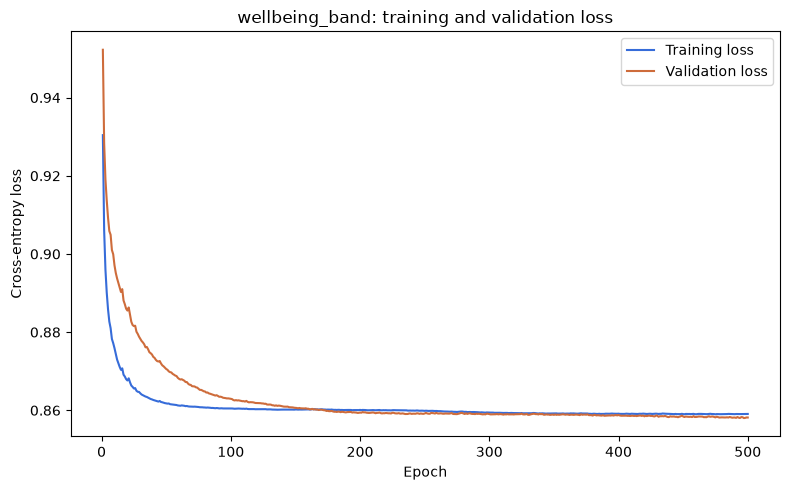

In [18]:
wellbeing_epochs = np.arange(1, len(history_wellbeing["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(wellbeing_epochs, history_wellbeing["train_loss"], label="Training loss")
plt.plot(wellbeing_epochs, history_wellbeing["validation_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("wellbeing_band: training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

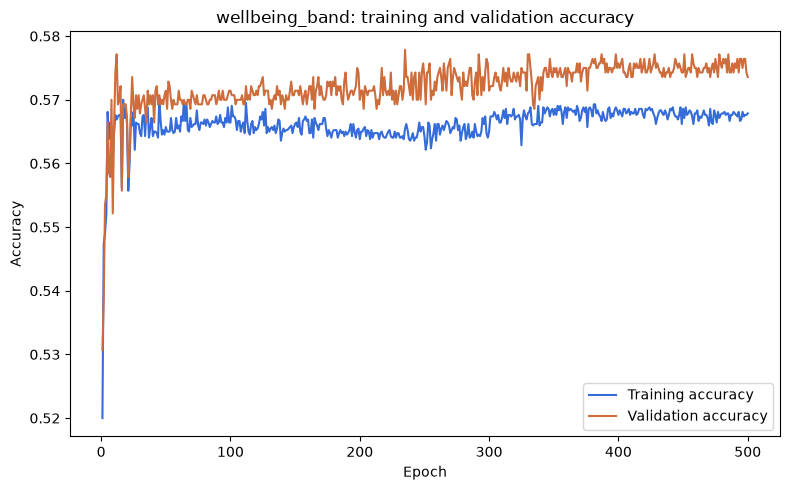

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(wellbeing_epochs, history_wellbeing["train_metric"], label="Training accuracy")
plt.plot(wellbeing_epochs, history_wellbeing["validation_metric"], label="Validation accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("wellbeing_band: training and validation accuracy")
plt.legend()
plt.tight_layout()
plt.show()

### training — life_satisfaction_1to10 regressor

In [20]:
layer_sizes_life_satisfaction = [X_train_processed.shape[1], 32, 16, 1]

parameters_life_satisfaction, history_life_satisfaction = train(
    X_train=X_train_processed,
    Y_train=y_life_satisfaction_train,
    X_validation=X_validation_processed,
    Y_validation=y_life_satisfaction_validation,
    layer_sizes=layer_sizes_life_satisfaction,
    learning_rate=0.01,
    epochs=500,
    batch_size=64,
    print_every=25,
    output_activation="linear",
    loss="mse",
    l2_lambda=1.0,
)

Epoch 0: train_loss=3.3131 val_loss=3.4930 train_metric=1.446 val_metric=1.476
Epoch 25: train_loss=2.4038 val_loss=2.6041 train_metric=1.241 val_metric=1.303
Epoch 50: train_loss=2.1747 val_loss=2.3299 train_metric=1.194 val_metric=1.238
Epoch 75: train_loss=2.1671 val_loss=2.2984 train_metric=1.190 val_metric=1.231
Epoch 100: train_loss=2.1940 val_loss=2.2869 train_metric=1.194 val_metric=1.226
Epoch 125: train_loss=2.1954 val_loss=2.3512 train_metric=1.196 val_metric=1.245
Epoch 150: train_loss=2.1666 val_loss=2.2886 train_metric=1.188 val_metric=1.229
Epoch 175: train_loss=2.1733 val_loss=2.3070 train_metric=1.190 val_metric=1.233
Epoch 200: train_loss=2.1754 val_loss=2.2795 train_metric=1.190 val_metric=1.226
Epoch 225: train_loss=2.1679 val_loss=2.2825 train_metric=1.188 val_metric=1.228
Epoch 250: train_loss=2.1747 val_loss=2.3039 train_metric=1.190 val_metric=1.233
Epoch 275: train_loss=2.1711 val_loss=2.2836 train_metric=1.189 val_metric=1.227
Epoch 300: train_loss=2.1981 val_

### life_satisfaction_1to10 test evaluation

In [21]:
life_satisfaction_test_predictions = predict(X_test_processed, parameters_life_satisfaction, output_activation="linear")
life_satisfaction_test_true = y_life_satisfaction_test.reshape(-1)

mae = mean_absolute_error(life_satisfaction_test_true, life_satisfaction_test_predictions)
rmse = np.sqrt(mean_squared_error(life_satisfaction_test_true, life_satisfaction_test_predictions))
r2 = r2_score(life_satisfaction_test_true, life_satisfaction_test_predictions)

print(f"MAE:  {mae:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")

MAE:  1.217
RMSE: 1.509
R^2:  0.160


### plot life_satisfaction_1to10 learning curves

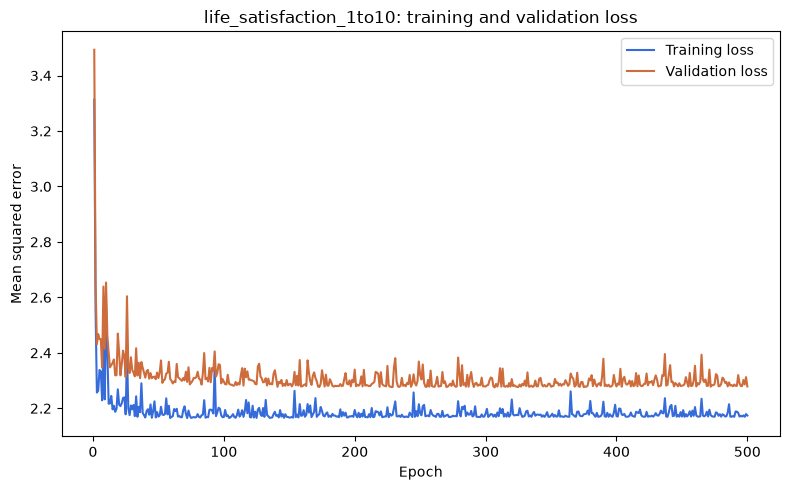

In [22]:
life_satisfaction_epochs = np.arange(1, len(history_life_satisfaction["train_loss"]) + 1)

plt.figure(figsize=(8, 5))

plt.plot(life_satisfaction_epochs, history_life_satisfaction["train_loss"], label="Training loss")
plt.plot(life_satisfaction_epochs, history_life_satisfaction["validation_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Mean squared error")
plt.title("life_satisfaction_1to10: training and validation loss")
plt.legend()
plt.tight_layout()
plt.show()

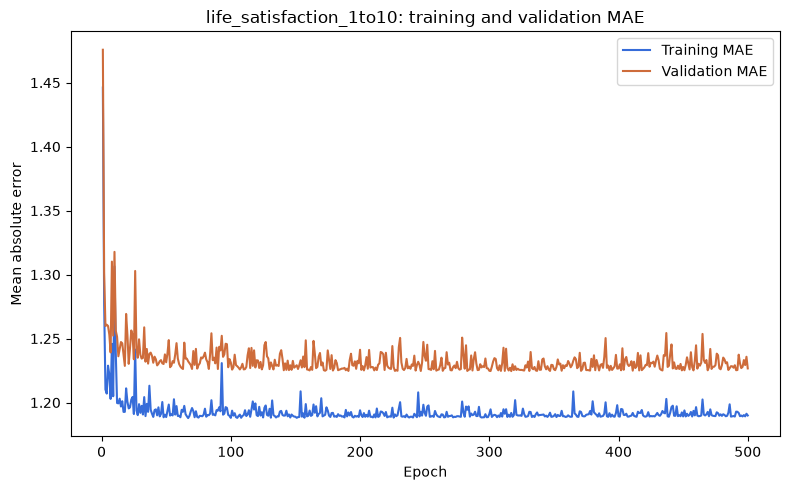

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(life_satisfaction_epochs, history_life_satisfaction["train_metric"], label="Training MAE")
plt.plot(life_satisfaction_epochs, history_life_satisfaction["validation_metric"], label="Validation MAE")

plt.xlabel("Epoch")
plt.ylabel("Mean absolute error")
plt.title("life_satisfaction_1to10: training and validation MAE")
plt.legend()
plt.tight_layout()
plt.show()

### save artifacts

In [24]:
# save the preprocessor and both models' weights so ui/app.py can load them
# uses its own subfolder so other notebooks (e.g. AI_try.ipynb) sharing "artifacts/"
# can't silently overwrite these files
ARTIFACTS_DIR = "artifacts/mood_predictor_v2"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

joblib.dump(preprocessor, f"{ARTIFACTS_DIR}/preprocessor.joblib")

def save_weights(parameters, path):
    weights = {}
    for i, layer in enumerate(parameters, start=1):
        weights[f"W{i}"] = layer["weights"]
        weights[f"b{i}"] = layer["biases"]
    np.savez(path, **weights)

save_weights(parameters_wellbeing, f"{ARTIFACTS_DIR}/wellbeing_model_weights.npz")
save_weights(parameters_life_satisfaction, f"{ARTIFACTS_DIR}/life_satisfaction_model_weights.npz")